Dataset shape: (14859, 2)
Unique moods: ['sedih' 'bahagia' 'cemas' 'marah' 'biasa saja']
Value counts:
MOOD
sedih         2972
bahagia       2972
marah         2972
biasa saja    2972
cemas         2971
Name: count, dtype: int64

Mood yang ditemukan: ['sedih' 'bahagia' 'cemas' 'marah' 'biasa saja']
Jumlah mood: 5


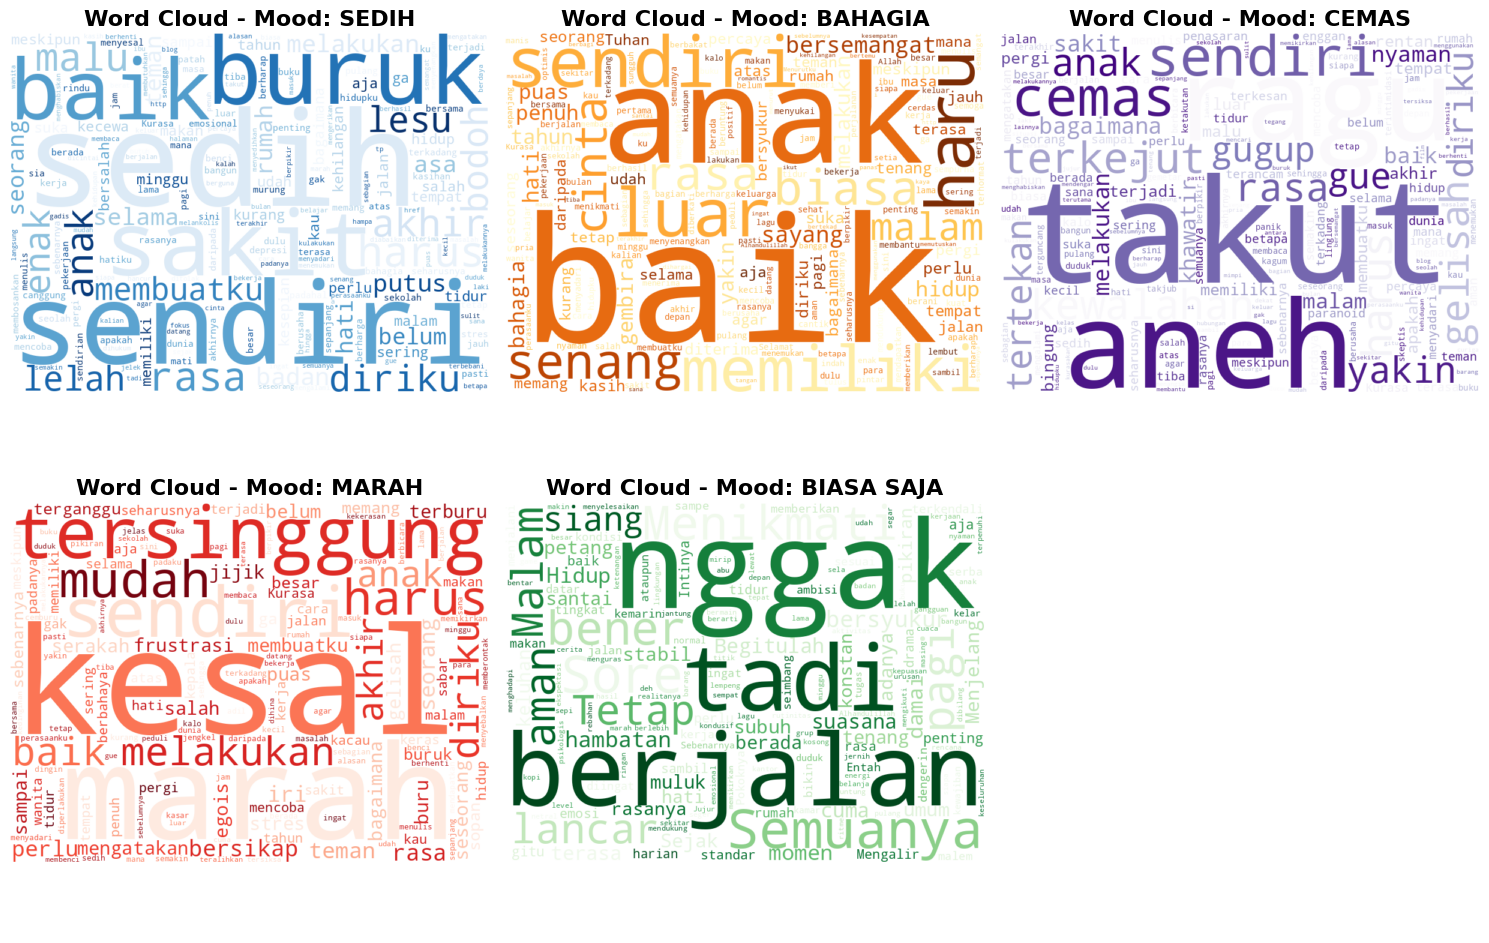


VERIFIKASI RESPON

Kelas [SEDIH]:
  - Jumlah Kata Kunci : 112 kata
  - Jumlah Respon     : 25 respon
  - Respon Valid (2 Kalimat): 25/25
  - Contoh Respon    : Nggak apa-apa kalau kamu butuh waktu buat nangis atau istirahat sebentar dari semuanya. Kasih waktu buat dirimu pulih, besok kita coba langkah kecil lagi karena aku yakin kamu pasti bisa.

Kelas [CEMAS]:
  - Jumlah Kata Kunci : 105 kata
  - Jumlah Respon     : 25 respon
  - Respon Valid (2 Kalimat): 25/25
  - Contoh Respon    : Tarik napas pelan-pelan ya, wajar banget kalau kamu merasa kewalahan dengan semua ketidakpastian ini. Nggak perlu buru-buru cari semua jawaban sekarang, pelan-pelan aja dan aku bakal temenin kamu.

Kelas [MARAH]:
  - Jumlah Kata Kunci : 120 kata
  - Jumlah Respon     : 25 respon
  - Respon Valid (2 Kalimat): 25/25
  - Contoh Respon    : Kamu berhak marah dan merasa direndahkan ketika perlakuan yang kamu terima memang nggak sepantasnya. Ambil waktu buat nenangin diri dulu, aku bakal selalu dukung kamu bua

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random
import itertools
import re

# ============================================================================
# 1. BACA DATASET
# ============================================================================
df = pd.read_csv("mood_jar.csv", encoding="cp1252")
df = df.dropna()

print(f"Dataset shape: {df.shape}")
print(f"Unique moods: {df['MOOD'].unique()}")
print(f"Value counts:\n{df['MOOD'].value_counts()}")

# ============================================================================
# 2. WORD CLOUD UNTUK SEMUA MOOD (TERMASUK "biasa saja")
# ============================================================================

color_maps = {
    "bahagia": "YlOrBr",
    "sedih": "Blues",
    "marah": "Reds",
    "cemas": "Purples",
    "biasa saja": "Greens"  # Ditambahkan untuk mood biasa saja
}

extended_stopwords = {
    'aku', 'saya', 'merasa', 'perasaan', 'dan', 'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'dengan',
    'karena', 'tidak', 'tak', 'bisa', 'akan', 'ada', 'adalah', 'sangat', 'lebih', 'bahwa', 'saat', 'jadi',
    'agak', 'kalau', 'jika', 'saja', 'juga', 'lah', 'kah', 'nya', 'tapi', 'tetapi', 'bgt', 'banget', 'kok',
    'loh', 'sih', 'ya', 'pas', 'malah', 'begitu', 'secara', 'tentang', 'oleh', 'bagi', 'pada', 'atau',
    'lalu', 'kemudian', 'setelah', 'sebelum', 'ketika', 'sementara', 'bahkan', 'namun', 'melainkan',
    'sedangkan', 'seperti', 'sebagai', 'terhadap', 'kepada', 'maupun', 'ia', 'kami', 'kita', 'kamu',
    'mereka', 'dia', 'anda', 'hal', 'orang', 'buat', 'banyak', 'bukan', 'pun', 'hanya', 'bisa', 'mampu',
    'dapat', 'ingin', 'mau', 'bila', 'terus', 'lagi', 'tahu', 'melihat', 'bilang', 'kata', 'katanya',
    'dalam', 'apa', 'sudah', 'telah', 'semua', 'masih', 'merasakan', 'menjadi', 'membuat', 'sama',
    'lain', 'sedang', 'hari', 'sedikit', 'diri', 'mulai', 'tahu-tahu', 'tahu2',
    'yg', 'mungkin', 'benar', 'benar-benar', 'sebuah', 'suatu', 'sesuatu', 'satu', 'dua', 'tiga',
    'kali', 'waktu', 'pernah', 'kembali', 'paling', 'terlalu', 'cukup', 'jangan', 'hampir',
    'sekarang', 'serta', 'tersebut', 'bagaikan', 'selalu', 'biasanya', 'punya', 'mengapa', 'kenapa',
    'beberapa', 'sekali', 'setiap', 'tanpa', 'baru'
}

# Dapatkan semua mood unik
moods = df['MOOD'].unique()
n_moods = len(moods)
print(f"\nMood yang ditemukan: {moods}")
print(f"Jumlah mood: {n_moods}")

# Buat grid yang cukup (3x2 = 6, aman untuk 5 mood)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, mood in enumerate(moods):
    # Gabungkan semua teks untuk mood tertentu
    text = " ".join(df[df['MOOD'] == mood]['MOOD_NOTE'].astype(str))

    # Buat word cloud
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        stopwords=extended_stopwords,
        min_font_size=10,
        colormap=color_maps.get(mood, 'viridis'),
        collocations=False
    ).generate(text)

    # Plot ke subplot
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud - Mood: {mood.upper()}", fontsize=16, fontweight='bold')
    axes[i].axis('off')

# Sembunyikan subplot yang tidak terpakai (ke-6)
if n_moods < len(axes):
    axes[n_moods].axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# 3. KATA KUNCI UNTUK SETIAP MOOD
# ============================================================================

KEYWORDS = {
    "sedih": [
        "sedih", "menangis", "nangis", "duka", "berduka", "kecewa", "hancur", "patah hati",
        "lelah", "capek", "letih", "lesu", "sakit", "pilu", "kesepian", "sendiri", "sepi",
        "murung", "kelabu", "air mata", "derita", "pedih", "perih", "tersakiti", "terluka",
        "luka", "ditinggalkan", "diabaikan", "ditolak", "gagal", "kegagalan", "terpuruk",
        "jatuh", "merana", "nelangsa", "meratap", "pesimis", "putus asa", "hampa", "kosong",
        "depresi", "trauma", "down", "tersisih", "menyerah", "pasrah", "beban", "berat",
        "hancur lebur", "kelam", "tangis", "stres", "melankolis", "sendu", "nestapa",
        "rapuh", "lemah", "tak berdaya", "menyesakkan", "sesak", "suram", "menangisi",
        "tertindas", "tersiksa", "merintih", "hancur hatiku", "kepedihan", "keputusasaan",
        "kemalangan", "tragis", "tersayat", "terbuang", "tak berguna", "tak berharga",
        "diremehkan", "dijauhi", "kesendirian", "terasing", "diasingkan", "sunyi", "senyap",
        "tak bermakna", "patah semangat", "letih lesu", "payah", "kehabisan tenaga",
        "terkuras", "ngantuk", "tak bersemangat", "tak bernapas", "runtuh", "terhempas",
        "tertimpa", "tergilas", "remuk", "redam", "berantakan", "ambyar", "menyesal",
        "nyesek", "baper", "nangis kejer", "tersedu", "lara", "sengsara", "patah arang",
        "nangis darah", "mengiba", "ngilu", "teriris", "kelam kabut", "gundah gulana"
    ],
    "cemas": [
        "cemas", "takut", "panik", "khawatir", "gelisah", "gugup", "deg-degan", "was-was",
        "waswas", "overthinking", "kepikiran", "bingung", "ragu", "bimbang", "tidak tahu",
        "pusing", "tertekan", "kewalahan", "overwhelmed", "stres", "beban pikiran", "tegang",
        "gemetar", "phobia", "fobia", "terancam", "bahaya", "tidak aman", "ngeri", "parno",
        "paranoid", "resah", "gundah", "gulana", "gentar", "ciut", "grogi", "nervous",
        "insecure", "minder", "pesimis", "keringat dingin", "merinding", "takut salah",
        "galau", "tidak pasti", "ketidakpastian", "cemas berlebih", "terbebani", "kalut",
        "buntu", "tidak tenang", "pikiran kacau", "tak menentu", "jantungan", "sesak napas",
        "histeris", "syok", "kaget", "terkejut", "ketakutan", "ketar-ketir", "waspada",
        "curiga", "wasangka", "tidak karuan", "pusing tujuh keliling", "kewalahan hidup",
        "terombang-ambing", "tersesat", "linglung", "tidak fokus", "blank", "kosong pikiran",
        "kalut hati", "risau", "insomnia", "tidak bisa tidur", "mimpi buruk", "trauma",
        "overaktif", "berdebar", "detak jantung", "pikiran negatif", "skenario buruk",
        "takut gagal", "takut ditolak", "takut masa depan", "cemas sosial", "takut bicara",
        "mikirin", "nggak tahu", "ragu-ragu",
        "degdegan", "pucat", "gelagapan", "tremor", "parnoan", "keringat jagung", "mual",
        "mules", "mondar-mandir", "kebat-kebit", "nggak tenang", "kepikiran terus"
    ],
    "marah": [
        "marah", "kesal", "emosi", "jengkel", "sebel", "bete", "benci", "muak", "murka",
        "dendam", "frustrasi", "amarah", "berang", "naik pitam", "gondok", "geram", "dongkol",
        "ngamuk", "mengamuk", "kecewa berat", "dikhianati", "dibohongi", "ditipu", "curang",
        "egois", "sombong", "arogan", "kasar", "hina", "dihina", "direndahkan", "disepelekan",
        "marah besar", "beringas", "sewot", "nyolot", "meledak", "sensi", "sensitif", "sinis",
        "sarkas", "menyindir", "bertengkar", "ribut", "berantem", "cekcok", "debat",
        "membenci", "mendendam", "iri", "dengki", "cemburu", "panas hati", "terbakar emosi",
        "mengumpat", "berteriak", "ngomel", "mengomel", "cerewet", "protes", "membantah",
        "jijik", "tidak adil", "diskriminasi", "pilih kasih", "dipermainkan", "dimanfaatkan",
        "ditikam", "dikibulin", "dibodohi", "dicurangi", "dirugikan", "dipaksa", "terpaksa",
        "memuakkan", "menjengkelkan", "menyebalkan", "meresahkan", "tidak menghargai",
        "tidak sopan", "kurang ajar", "brengsek", "biadab", "kejam", "zalim", "menindas",
        "memeras", "provokasi", "dipancing", "terpancing", "tantang", "menantang", "agresif",
        "destruktif", "merusak", "membanting", "memukul", "unfair", "tidak fair",
        "emosian", "naik darah", "muntab", "spaneng", "meletup", "mendidih", "meradang",
        "mencak-mencak", "bacot", "ngegas", "nyebelin", "ngeselin", "bikin emosi", "toxic",
        "keparat", "bangsat", "anjing", "mangkel", "misuh", "bangke", "sialan"
    ],
    "bahagia": [
        "bahagia", "senang", "gembira", "ceria", "riang", "senyum", "tawa", "tertawa",
        "bangga", "sukses", "berhasil", "menang", "juara", "lulus", "diterima", "pencapaian",
        "cinta", "sayang", "kasih", "asmara", "romantis", "bersyukur", "alhamdulillah",
        "puji tuhan", "berterima kasih", "lega", "plong", "damai", "tenang", "antusias",
        "semangat", "optimis", "excited", "motivasi", "energi", "positif", "berbunga-bunga",
        "terharu", "takjub", "luar biasa", "fantastis", "keren", "mantap", "hebat", "asik",
        "seru", "menyenangkan", "memuaskan", "rindu terbalas", "kasmaran", "jatuh cinta",
        "cinta mati", "berseri-seri", "sumringah", "girang", "kegirangan", "sorak", "bersorak",
        "beruntung", "hoki", "rezeki", "berkah", "anugerah", "mukjizat", "kejutan", "hadiah",
        "perayaan", "merayakan", "syukuran", "pesta", "liburan", "healing",
        "nyaman", "aman", "tenteram", "sentosa", "sejahtera", "makmur", "kaya", "melimpah",
        "tercapai", "terwujud", "impian", "cita-cita", "harapan", "gemilang", "brilian",
        "pintar", "cerdas", "diakui", "dipuji", "dihargai", "dihormati", "disayang",
        "diperhatikan", "dipedulikan", "dimengerti", "dipahami", "keajaiban", "sempurna",
        "indah", "cantik", "tampan", "mempesona",
        "hepi", "happy", "sukacita", "full senyum", "semringah", "syahdu", "rezeki nomplok",
        "maknyus", "mantul", "gacor", "melayang", "ngakak", "haha", "wkwk", "xixi", "blessed"
    ],
    "biasa saja": [
        "biasa saja", "biasa", "netral", "datar", "mager", "santai", "standar", "aman",
        "lumayan", "nggak ada apa-apa", "tenang", "seimbang", "cukup", "gitu deh",
        "ngelamun", "nggak ada drama", "rileks", "tipikal", "pas", "nggak seneng banget",
        "nggak sedih juga", "terkendali", "rebahan", "cukup produktif", "jalan aja",
        "b aja", "b-aja", "so so", "ya gitu", "gabut", "chilling", "chill", "leyeh-leyeh",
        "males-malesan", "numpang lewat", "nggak ada yang spesial", "let it flow",
        "mengalir aja", "staycation", "ngopi", "nongkrong santai", "slow", "selow", "nyantui", "nyantai"
    ]
}

# ============================================================================
# 4. PARAGRAF RESPON (2 KALIMAT) UNTUK SETIAP MOOD
# ============================================================================

PARTS = {
    "sedih": {
        "s1": [
            "Aku ngerti banget ini masa yang berat buat kamu, dan gapapa kok kalau hari ini kamu ngerasa capek.",
            "Dengar ceritamu, aku bisa ngerasain betapa melelahkannya situasi yang lagi kamu hadapin sekarang.",
            "Wajar banget kalau kamu merasa hancur atau kecewa, perasaan sedihmu itu valid kok.",
            "Nggak apa-apa kalau kamu butuh waktu buat nangis atau istirahat sebentar dari semuanya.",
            "Aku tahu beban yang lagi kamu pikul ini berat banget, dan kamu udah berusaha sebaik mungkin."
        ],
        "s2": [
            "Kamu nggak sendirian ngelewatin ini, aku ada di sini buat nemenin kamu pelan-pelan bangkit lagi ya.",
            "Kasih waktu buat dirimu pulih, besok kita coba langkah kecil lagi karena aku yakin kamu pasti bisa.",
            "Jangan ragu buat cerita kapan pun kamu butuh teman, karena kamu selalu punya tempat buat bersandar.",
            "Meskipun sekarang rasanya gelap banget, pelan-pelan pasti bakal ada titik terangnya kok, semangat ya!",
            "Peluk jauh dari sini, semoga hari esok bisa ngasih sedikit rasa lega buat hatimu yang lagi capek."
        ]
    },
    "cemas": {
        "s1": [
            "Tarik napas pelan-pelan ya, wajar banget kalau kamu merasa kewalahan dengan semua ketidakpastian ini.",
            "Kecemasan yang kamu rasain itu valid, dan aku tahu pikiranmu pasti lagi berisik banget sekarang.",
            "Pasti rasanya nggak enak banget ya ngerasa panik dan deg-degan kayak gini.",
            "Aku ngerti kamu lagi takut dan overthinking, wajar kok kalau sesekali kita merasa kewalahan.",
            "Nggak apa-apa merasa gugup, itu tanda kalau kamu peduli sama hal yang lagi kamu hadapi ini."
        ],
        "s2": [
            "Yuk, coba fokus ke hal-hal kecil yang bisa kamu kontrol hari ini aja, pelan-pelan pasti badainya reda.",
            "Kamu jauh lebih kuat dari rasa takutmu, dan aku yakin banget kamu bisa ngelewatin ini semua.",
            "Nggak perlu buru-buru cari semua jawaban sekarang, pelan-pelan aja dan aku bakal temenin kamu.",
            "Semuanya bakal baik-baik aja kok, kamu udah pernah ngelewatin masa sulit sebelumnya dan kali ini pun pasti bisa.",
            "Kapan pun kamu butuh bantuan buat nenangin pikiran, aku siap dengerin ceritamu sampai kamu merasa baikan."
        ]
    },
    "marah": {
        "s1": [
            "Aku paham banget kenapa kamu merasa sekesal ini, wajar kalau kamu marah karena situasinya memang nggak adil.",
            "Rasa kecewa dan emosimu itu manusiawi banget, apalagi kalau usahamu nggak dihargai.",
            "Denger ceritamu, siapapun pasti bakal ikutan gondok dan ngerasa muak sama situasi kayak gini.",
            "Wajar kok kalau kamu meledak, menahan rasa jengkel yang kelewat batas emang nggak baik buat kamu.",
            "Kamu berhak marah dan merasa direndahkan ketika perlakuan yang kamu terima memang nggak sepantasnya."
        ],
        "s2": [
            "Keluarin aja semua unek-unekmu sampai lega, habis itu kita pakai energimu buat hal yang lebih positif ya.",
            "Jangan biarin mereka merusak harimu terlalu lama, kamu jauh lebih berharga dari situasi yang nyebelin ini.",
            "Ambil waktu buat nenangin diri dulu, aku bakal selalu dukung kamu buat nemuin solusi yang terbaik.",
            "Setelah emosimu reda nanti, aku yakin kamu bisa ngambil keputusan dengan jauh lebih bijak dan elegan.",
            "Aku ada di sini buat jadi tempat sampah kekesalanmu, yuk lepaskan semuanya biar hatimu lebih lega."
        ]
    },
    "bahagia": {
        "s1": [
            "Wah, ikut seneng banget dengar kabar baik dari kamu hari ini, senyummu nular banget!",
            "Pencapaianmu ini luar biasa, kamu emang pantas banget buat ngerayain momen seru ini.",
            "Alhamdulillah! Denger cerita bahagiamu bikin aku ikut ngerasain energi positif yang luar biasa.",
            "Segala kerja keras dan perjuanganmu akhirnya kebayar lunas ya, aku bangga banget sama kamu!",
            "Seru banget! Momen manis kayak gini emang paling pas buat disyukuri dan dirayain bareng-bareng."
        ],
        "s2": [
            "Semoga hari-harimu ke depan makin banyak kejutan seru dan keberuntungan kayak gini ya, terus semangat!",
            "Jadikan momen bahagia ini energi tambahan buat ngejar mimpi-mimpimu yang lebih besar lagi, selamat ya!",
            "Jangan lupa kasih reward buat dirimu sendiri ya, kamu pantes dapetin semua kebahagiaan ini.",
            "Aku bakal selalu ada buat ikut bersorak di setiap keberhasilanmu, terus tebar energi positif ini ya!",
            "Nikmatin perasaan damai dan seneng ini sepuasnya, semoga kebahagiaan ini menetap lama di hatimu."
        ]
    },
    "biasa saja": {
        "s1": [
            "Wah, hari yang santai dan aman-aman aja kayak gini juga patut disyukuri lho.",
            "Keliatannya hari ini berjalan cukup tenang ya, kadang kita emang butuh momen buat bersantai.",
            "Nggak ada salahnya kok punya hari yang biasa-biasa aja, yang penting kamu ngerasa rileks.",
            "Hari yang standar gini kadang justru jadi waktu istirahat yang paling berharga buat pikiran kita.",
            "Mager dan pengen santai aja itu wajar banget, sesekali tubuh kita emang butuh istirahat gasiii."
        ],
        "s2": [
            "Nikmatin aja ketenangan hari ini buat nge-charge energimu ya, selamat bersantai!",
            "Semoga sisa harimu tetap aman terkendali sampai waktu istirahat nanti malam.",
            "Bagus deh kalau nggak ada beban pikiran yang aneh-aneh hari ini, pakai waktumu buat lakuin hal yang kamu suka ya.",
            "Yuk, manfaatin waktu luang ini buat ngopi santai atau sekadar rebahan sambil ngelamun.",
            "Tetap jaga mood stabilmu ini ya, besok kita siap hadapi aktivitas dengan energi yang lebih fresh!"
        ]
    }
}

# ============================================================================
# 5. GENERATE RESPON (2 KALIMAT)
# ============================================================================

def generate_dataset(seed=42, max_per_label=100):
    random.seed(seed)
    dataset = {}

    for label, sentences in PARTS.items():
        all_combinations = list(itertools.product(
            sentences["s1"],
            sentences["s2"]
        ))

        random.shuffle(all_combinations)

        dataset[label] = [
            " ".join(combo)
            for combo in all_combinations[:max_per_label]
        ]

    return dataset

SUPPORT_RESPONSES = generate_dataset()

def generate_support_from_label(label):
    label = label.lower().strip()
    if label not in SUPPORT_RESPONSES:
        label = "biasa saja"
    return random.choice(SUPPORT_RESPONSES[label])

# ============================================================================
# 6. VERIFIKASI
# ============================================================================

print("\n" + "="*60)
print("VERIFIKASI RESPON")
print("="*60)

for label, paragraphs in SUPPORT_RESPONSES.items():
    print(f"\nKelas [{label.upper()}]:")
    print(f"  - Jumlah Kata Kunci : {len(KEYWORDS[label])} kata")
    print(f"  - Jumlah Respon     : {len(paragraphs)} respon")

    valid_paragraphs = sum(1 for p in paragraphs if len(re.findall(r'[.!?]+', p)) == 2)
    print(f"  - Respon Valid (2 Kalimat): {valid_paragraphs}/{len(paragraphs)}")

    # Tampilkan contoh respon
    print(f"  - Contoh Respon    : {paragraphs[0]}")

# ============================================================================
# 7. TAMBAHKAN SUPPORT MESSAGE KE DATASET
# ============================================================================


support_messages = []

for idx, row in df.iterrows():
    text = row["MOOD_NOTE"]
    label = row["MOOD"]

    response_msg = generate_support_from_label(label)
    support_messages.append(response_msg)

    # Tampilkan beberapa contoh saja (10 pertama)
    if idx < 10:
        print(f"\n[{idx+1}] INPUT: \"{text[:100]}...\"")
        print(f"    MOOD : {label.upper()}")
        print(f"    RESPON: {response_msg}")

# Tambahkan kolom support_message
df["support_message"] = support_messages

# ============================================================================
# 8. SIMPAN HASIL
# ============================================================================

# Tampilkan preview hasil
print("\nPreview 5 data pertama:")
print(df[["MOOD", "MOOD_NOTE", "support_message"]].head())

# Simpan ke file CSV
df.to_csv("moodJarSupportMessagesFinal.csv", index=False)